In [5]:
import torch, os
import numpy as np
from classifier_model import BG
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

n_iter = 100

dt = 0.002
num_steps = 1000
rl_scaler = 1
units = 64

min_omega = 30
max_omega = 60

input_dim = 1
action_dim = 2

In [7]:
PD_FLAG = 0
load_folder = f'tbi_ms_pd{PD_FLAG}/'

if not os.path.exists(load_folder):
    raise FileNotFoundError(f"Load folder {load_folder} does not exist.")

num_iterations = 50
master_zipper_s = []
master_zipper_l = []

for ni in range(num_iterations): 

    model = BG(input_dim, action_dim, units, dt,
                min_omega, max_omega, pd_flag=PD_FLAG)
    model.load_state_dict(torch.load(f'{load_folder}model.pth'))
    model.d1.omegas.data = torch.tensor(np.load(f'{load_folder}d1_omegas.npy'))
    model.d2.omegas.data = torch.tensor(np.load(f'{load_folder}d2_omegas.npy'))

    offset = int(0.4/(dt * rl_scaler))
    t_stimuli = np.arange(0, offset*dt*rl_scaler, dt)
    t_noise = np.arange(0, (num_steps-offset)*dt*rl_scaler, dt)
    state_stimuli = 5*np.sin(2*np.pi*10*t_stimuli)
    state_noise = np.sin(2*np.pi*10*t_noise) 
    state = np.hstack((state_stimuli, state_noise))
    state = torch.tensor(state, dtype=torch.float32).reshape(-1, 1, 1)
    (pred, value, zipper_s) = model(state)
    master_zipper_s.append(zipper_s)

    offset = int(1.6/(dt * rl_scaler))
    t_stimuli = np.arange(0, offset*dt*rl_scaler, dt)
    t_noise = np.arange(0, (num_steps-offset)*dt*rl_scaler, dt)
    state_stimuli = 5*np.sin(2*np.pi*10*t_stimuli)
    state_noise = np.sin(2*np.pi*10*t_noise) 
    state = np.hstack((state_stimuli, state_noise))
    state = torch.tensor(state, dtype=torch.float32).reshape(-1, 1, 1)
    (pred, value, zipper_l) = model(state)
    master_zipper_l.append(zipper_l)

In [8]:
PD_FLAG = 1
load_folder = f'tbi_ms_pd{PD_FLAG}/'
if not os.path.exists(load_folder):
    raise FileNotFoundError(f"Load folder {load_folder} does not exist.")
master_pd_zipper_s = []
master_pd_zipper_l = []

for ni in range(num_iterations):
    pd_model = BG(input_dim, action_dim, units, dt,
                min_omega, max_omega, pd_flag=PD_FLAG)
    pd_model.load_state_dict(torch.load(f'{load_folder}model.pth'))
    pd_model.d1.omegas.data = torch.tensor(np.load(f'{load_folder}d1_omegas.npy'))
    pd_model.d2.omegas.data = torch.tensor(np.load(f'{load_folder}d2_omegas.npy'))

    offset = int(0.4/(dt * rl_scaler))
    t_stimuli = np.arange(0, offset*dt*rl_scaler, dt)
    t_noise = np.arange(0, (num_steps-offset)*dt*rl_scaler, dt)
    state_stimuli = 5*np.sin(2*np.pi*10*t_stimuli)
    state_noise = np.sin(2*np.pi*10*t_noise) 
    state = np.hstack((state_stimuli, state_noise))
    state = torch.tensor(state, dtype=torch.float32).reshape(-1, 1, 1)
    (pred, value, pd_zipper_s) = pd_model(state)
    master_pd_zipper_s.append(pd_zipper_s) 
    
    offset = int(1.6/(dt * rl_scaler))
    t_stimuli = np.arange(0, offset*dt*rl_scaler, dt)
    t_noise = np.arange(0, (num_steps-offset)*dt*rl_scaler, dt)
    state_stimuli = 5*np.sin(2*np.pi*10*t_stimuli)
    state_noise = np.sin(2*np.pi*10*t_noise) 
    state = np.hstack((state_stimuli, state_noise))
    state = torch.tensor(state, dtype=torch.float32).reshape(-1, 1, 1)
    (pred, value, pd_zipper_l) = pd_model(state)
    master_pd_zipper_l.append(pd_zipper_l)

In [10]:
load_folder = f'tbi_ms_sc{0}/'
if not os.path.exists(load_folder):
    raise FileNotFoundError(f"Load folder {load_folder} does not exist.")

master_sh_zipper_s = []
master_sh_zipper_l = []

for ni in range(num_iterations):
    sh_model = BG(input_dim, action_dim, units, dt,
                min_omega, max_omega, sc_flag=1)
    sh_model.load_state_dict(torch.load(f'{load_folder}model.pth'))
    sh_model.d1.omegas.data = torch.tensor(np.load(f'{load_folder}d1_omegas.npy'))
    sh_model.d2.omegas.data = torch.tensor(np.load(f'{load_folder}d2_omegas.npy'))

    offset = int(0.4/(dt * rl_scaler))
    t_stimuli = np.arange(0, offset*dt*rl_scaler, dt)
    t_noise = np.arange(0, (num_steps-offset)*dt*rl_scaler, dt)
    state_stimuli = 5*np.sin(2*np.pi*10*t_stimuli)
    state_noise = np.sin(2*np.pi*10*t_noise) 
    state = np.hstack((state_stimuli, state_noise))
    state = torch.tensor(state, dtype=torch.float32).reshape(-1, 1, 1)
    (pred, value, sh_zipper_s) = sh_model(state)
    master_sh_zipper_s.append(sh_zipper_s)

    offset = int(1.6/(dt * rl_scaler))
    t_stimuli = np.arange(0, offset*dt*rl_scaler, dt)
    t_noise = np.arange(0, (num_steps-offset)*dt*rl_scaler, dt)
    state_stimuli = 5*np.sin(2*np.pi*10*t_stimuli)
    state_noise = np.sin(2*np.pi*10*t_noise) 
    state = np.hstack((state_stimuli, state_noise))
    state = torch.tensor(state, dtype=torch.float32).reshape(-1, 1, 1)
    (pred, value, sh_zipper_l) = sh_model(state)
    master_sh_zipper_l.append(sh_zipper_l)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

nc_d1_short = []
nc_d1_long = []
pd_d1_short = []
pd_d1_long = []
sh_d1_short = []
sh_d1_long = []

nc_value_short = []
nc_value_long = []
pd_value_short = []
pd_value_long = []
sh_value_short = []
sh_value_long = []

for k in range(num_iterations):
    
    nc_d1_short.append(np.real(master_zipper_s[k]['d1'][:,0,:].T))  # shape: (num_oscillators, num_timepoints)
    nc_d1_long.append(np.real(master_zipper_l[k]['d1'][:,0,:].T))  # shape: (num_oscillators, num_timepoints)

    pd_d1_short.append(np.real(master_pd_zipper_s[k]['d1'][:,0,:].T))  # shape: (num_oscillators, num_timepoints)
    pd_d1_long.append(np.real(master_pd_zipper_l[k]['d1'][:,0,:].T))  # shape: (num_oscillators, num_timepoints)

    sh_d1_short.append(np.real(master_sh_zipper_s[k]['d1'][:,0,:].T))  # shape: (num_oscillators, num_timepoints)
    sh_d1_long.append(np.real(master_sh_zipper_l[k]['d1'][:,0,:].T))  # shape: (num_oscillators, num_timepoints)

    nc_value_short.append(master_zipper_s[k]['value'].flatten())
    nc_value_long.append(master_zipper_l[k]['value'].flatten())
    pd_value_short.append(master_pd_zipper_s[k]['value'].flatten())
    pd_value_long.append(master_pd_zipper_l[k]['value'].flatten())
    sh_value_short.append(master_sh_zipper_s[k]['value'].flatten())
    sh_value_long.append(master_sh_zipper_l[k]['value'].flatten())

dt = 0.002
fs = 1 / dt  # 500 Hz

plt.rcParams.update({'font.size': 14})
plt.rcParams.update({'figure.dpi': 400})


/var/folders/cr/sbxs5z551zz25_qrb4x_32dr0000gn/T/ipykernel_34244/884661995.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(power[mask], freqs[mask])


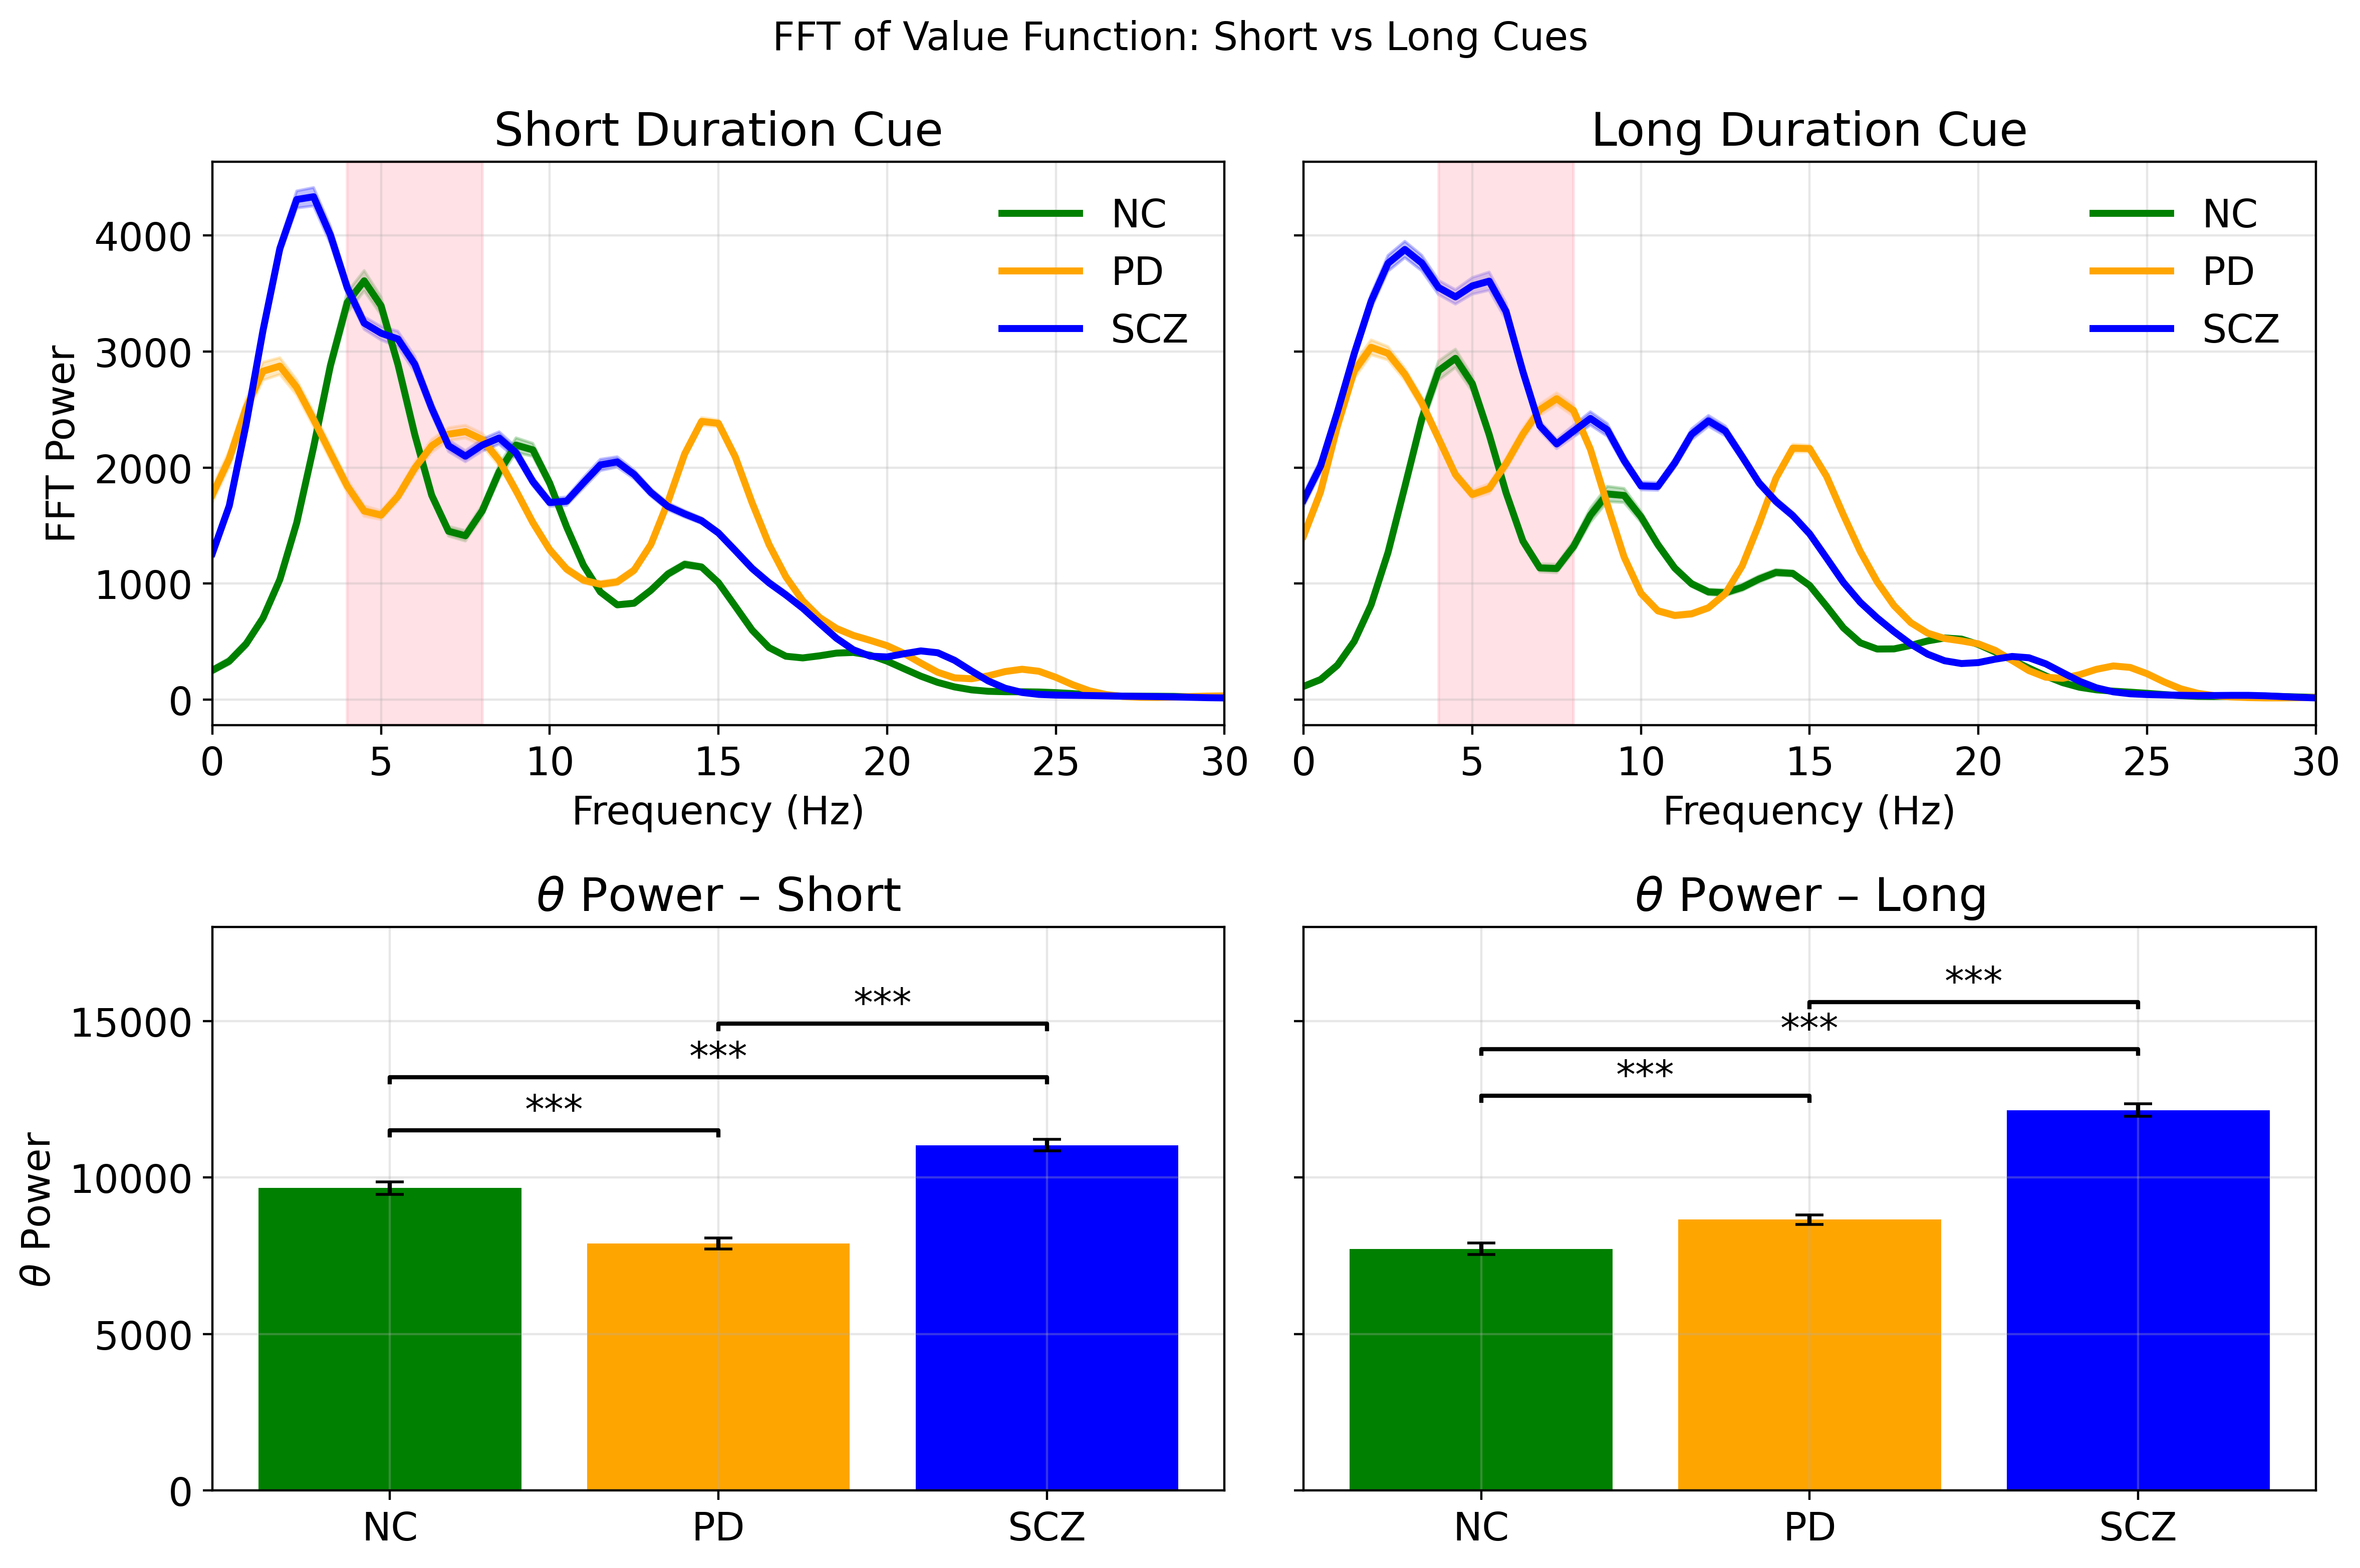

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ttest_ind

# ---------------- Parameters ----------------
dt = 0.002
fs = 1 / dt
theta_band = (4, 8)
smooth_sigma = 2
fmax = 30

plt.rcParams.update({'font.size': 14})
plt.rcParams.update({'figure.dpi': 400})

# ---------------- Helper functions ----------------
def compute_fft_power(signal, dt):
    signal = np.asarray(signal)
    signal = signal - np.mean(signal)
    T = signal.shape[0]
    fft_vals = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(T, d=dt)
    power = np.abs(fft_vals) ** 2
    return freqs, power

def theta_power(freqs, power, band=(4, 8)):
    mask = (freqs >= band[0]) & (freqs <= band[1])
    return np.trapz(power[mask], freqs[mask])

def significance_label(p):
    if p < 1e-3:
        return '***'
    elif p < 1e-2:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

def add_sig(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='k')
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom')

# ---------------- Stack if lists ----------------
def ensure_array(x):
    if isinstance(x, list):
        return np.stack(x)
    return np.asarray(x)

nc_value_short = ensure_array(nc_value_short)
pd_value_short = ensure_array(pd_value_short)
sh_value_short = ensure_array(sh_value_short)

nc_value_long = ensure_array(nc_value_long)
pd_value_long = ensure_array(pd_value_long)
sh_value_long = ensure_array(sh_value_long)

# ---------------- Data ----------------
short_data = {
    'NC': nc_value_short,
    'PD': pd_value_short,
    'SCZ': sh_value_short
}

long_data = {
    'NC': nc_value_long,
    'PD': pd_value_long,
    'SCZ': sh_value_long
}

colors = {
    'NC': 'green',
    'PD': 'orange',
    'SCZ': 'blue'
}

labels = list(short_data.keys())
x = np.arange(len(labels))

# ---------------- Plot Layout ----------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    gridspec_kw={'height_ratios': [1, 1]},
    sharey='row'
)

theta_short_vals = {}
theta_long_vals = {}

# ----------- TOP ROW: FFT mean ± std -----------
for ax, data, title, store in zip(
        axes[0],
        [short_data, long_data],
        ['Short Duration Cue', 'Long Duration Cue'],
        [theta_short_vals, theta_long_vals]):

    for label, signals in data.items():

        signals = ensure_array(signals)

        trial_power = []
        theta_trials = []

        for s in signals:
            freqs, power = compute_fft_power(s, dt)
            power = gaussian_filter1d(power, sigma=smooth_sigma)

            trial_power.append(power)
            theta_trials.append(theta_power(freqs, power, theta_band))

        trial_power = np.asarray(trial_power)

        mean_power = trial_power.mean(axis=0)
        std_power = trial_power.std(axis=0)

        store[label] = np.asarray(theta_trials)

        ax.plot(freqs, mean_power,
                color=colors[label],
                lw=2.5,
                label=label)

        ax.fill_between(freqs,
                        mean_power - std_power,
                        mean_power + std_power,
                        color=colors[label],
                        alpha=0.25)

    ax.axvspan(theta_band[0], theta_band[1],
               color='lightpink', alpha=0.4)

    ax.set_xlim(0, fmax)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

axes[0, 0].set_ylabel('FFT Power')

# ----------- Bottom bars: mean ± std -----------
short_means = [theta_short_vals[l].mean() for l in labels]
short_stds  = [theta_short_vals[l].std()  for l in labels]

long_means  = [theta_long_vals[l].mean() for l in labels]
long_stds   = [theta_long_vals[l].std()  for l in labels]

axes[1,0].bar(
    x,
    short_means,
    yerr=short_stds,
    capsize=5,
    color=[colors[l] for l in labels]
)

axes[1,1].bar(
    x,
    long_means,
    yerr=long_stds,
    capsize=5,
    color=[colors[l] for l in labels]
)

axes[1,0].set_xticks(x)
axes[1,1].set_xticks(x)

axes[1,0].set_xticklabels(labels)
axes[1,1].set_xticklabels(labels)

axes[1,0].set_ylabel(r'$\theta$ Power')
axes[1,0].set_title(r'$\theta$ Power – Short')
axes[1,1].set_title(r'$\theta$ Power – Long')

axes[1,0].grid(alpha=0.3)
axes[1,1].grid(alpha=0.3)

axes[1, 0].set_ylim(0, 18000)

# ----------- Welch t-test significance -----------
pairs = [(0,1),(0,2),(1,2)]

# Short
y_base = max(short_means)+max(short_stds)*1.5
step = y_base*0.15

for i,(a,b) in enumerate(pairs):
    d1 = theta_short_vals[labels[a]]
    d2 = theta_short_vals[labels[b]]
    _,p = ttest_ind(d1,d2,equal_var=False)

    add_sig(axes[1,0], a, b, y_base+i*step, step*0.1, significance_label(p))

# Long
y_base = max(long_means)+max(long_stds)*1.5
step = y_base*0.12

for i,(a,b) in enumerate(pairs):
    d1 = theta_long_vals[labels[a]]
    d2 = theta_long_vals[labels[b]]
    _,p = ttest_ind(d1,d2,equal_var=False)

    add_sig(axes[1,1], a, b, y_base+i*step, step*0.1, significance_label(p))

# ----------- Title / Save -----------
plt.suptitle('FFT of Value Function: Short vs Long Cues', fontsize=14)
plt.tight_layout()
plt.savefig('theta_stats.png', dpi=400)
plt.show()

In [56]:
np.save('theta_data.npy', {'short': short_data, 'long': long_data}, allow_pickle=True)

/var/folders/cr/sbxs5z551zz25_qrb4x_32dr0000gn/T/ipykernel_34244/2022038842.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(power[mask], freqs[mask])


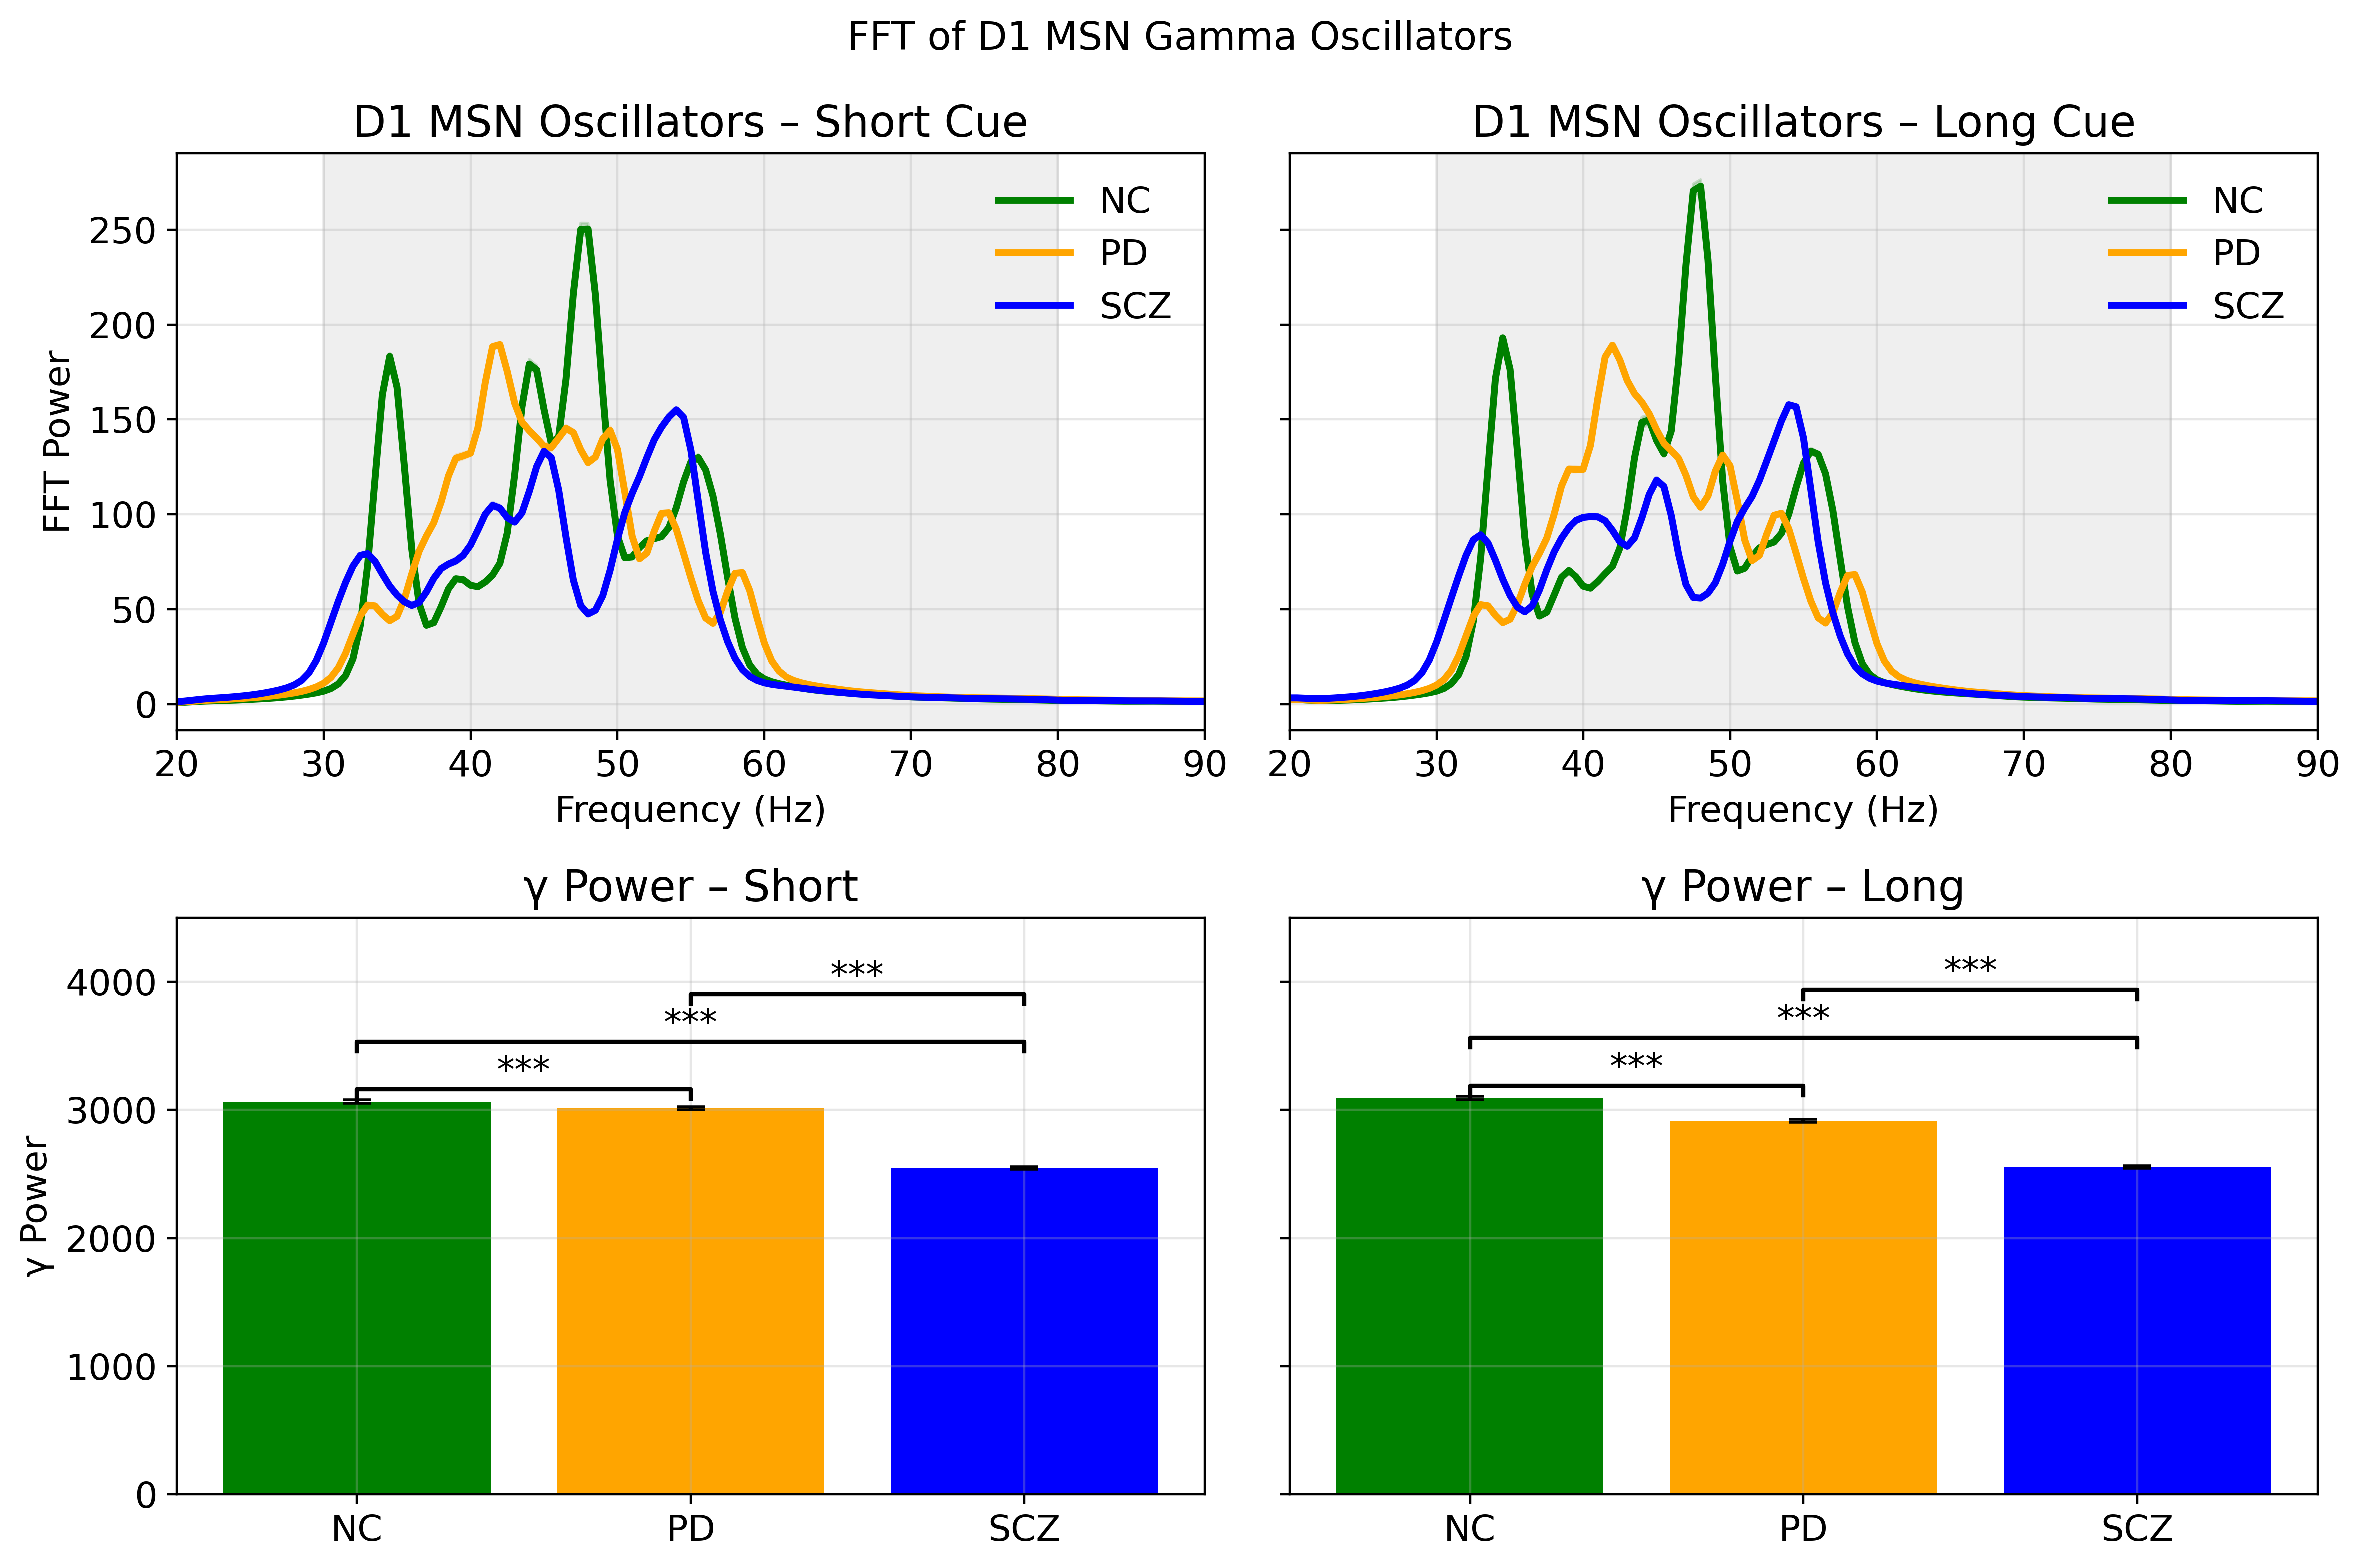

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ttest_ind

# ---------------- Parameters ----------------
dt = 0.002
gamma_band = (30, 80)
smooth_sigma = 2
fmin, fmax = 20, 80

plt.rcParams.update({'font.size': 13, 'figure.dpi': 400})

# ---------------- Helpers ----------------
def ensure_array(x):
    if isinstance(x, list):
        return np.stack(x)
    return np.asarray(x)

def compute_fft_power(signal, dt):
    signal = signal - np.mean(signal)
    T = signal.shape[0]
    fft_vals = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(T, d=dt)
    power = np.abs(fft_vals)**2
    return freqs, power

def band_power(freqs, power, band):
    mask = (freqs >= band[0]) & (freqs <= band[1])
    return np.trapz(power[mask], freqs[mask])

def significance_label(p):
    if p < 1e-3: return '***'
    if p < 1e-2: return '**'
    if p < 0.05: return '*'
    return 'n.s.'

def add_sig(ax, x1, x2, y, h, text):
    ax.plot([x1,x1,x2,x2],[y,y+h,y+h,y], lw=1.5, c='k')
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom')

# ---------------- Stack ----------------
nc_d1_short = ensure_array(nc_d1_short)
pd_d1_short = ensure_array(pd_d1_short)
sh_d1_short = ensure_array(sh_d1_short)

nc_d1_long = ensure_array(nc_d1_long)
pd_d1_long = ensure_array(pd_d1_long)
sh_d1_long = ensure_array(sh_d1_long)

# shape = trials, oscillators, time

short_data = {'NC':nc_d1_short,'PD':pd_d1_short,'SCZ':sh_d1_short}
long_data  = {'NC':nc_d1_long,'PD':pd_d1_long,'SCZ':sh_d1_long}

colors = {'NC':'green','PD':'orange','SCZ':'blue'}
labels = list(short_data.keys())
x = np.arange(len(labels))

# ---------------- Figure ----------------
fig, axes = plt.subplots(
    2,2,
    figsize=(12,8),
    gridspec_kw={'height_ratios':[1,1]},
    sharey='row'
)

gamma_short_vals={}
gamma_long_vals={}

# -------- FFT mean ± std --------
for ax,data,title,store in zip(
    axes[0],
    [short_data,long_data],
    ['D1 MSN Oscillators – Short Cue','D1 MSN Oscillators – Long Cue'],
    [gamma_short_vals,gamma_long_vals]
):

    for label,trials in data.items():

        trials = ensure_array(trials)

        trial_power=[]
        gamma_trials=[]

        for trial in trials:
            signal = trial.mean(axis=0)  # avg oscillators

            freqs,power = compute_fft_power(signal,dt)
            power = gaussian_filter1d(power,sigma=smooth_sigma)

            trial_power.append(power)
            gamma_trials.append(band_power(freqs,power,gamma_band))

        trial_power=np.asarray(trial_power)

        mean_power=trial_power.mean(0)
        std_power=trial_power.std(0)

        store[label]=np.asarray(gamma_trials)

        ax.plot(freqs,mean_power,color=colors[label],lw=2.5,label=label)
        ax.fill_between(freqs,
                        mean_power-std_power,
                        mean_power+std_power,
                        color=colors[label],alpha=0.25)

    ax.axvspan(*gamma_band,color='lightgray',alpha=0.35)
    ax.set_xlim(fmin,fmax)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

axes[0,0].set_ylabel('FFT Power')

# -------- Bars --------
short_means=[gamma_short_vals[l].mean() for l in labels]
short_stds =[gamma_short_vals[l].std() for l in labels]

long_means=[gamma_long_vals[l].mean() for l in labels]
long_stds =[gamma_long_vals[l].std() for l in labels]

axes[1,0].bar(x,short_means,yerr=short_stds,capsize=5,
              color=[colors[l] for l in labels])
axes[1,1].bar(x,long_means,yerr=long_stds,capsize=5,
              color=[colors[l] for l in labels])

axes[1,0].set_xticks(x);axes[1,1].set_xticks(x)
axes[1,0].set_xticklabels(labels);axes[1,1].set_xticklabels(labels)
axes[1,0].set_ylabel('γ Power')
axes[1,0].set_title('γ Power – Short')
axes[1,1].set_title('γ Power – Long')
axes[1, 0].grid(alpha=0.3)
axes[1, 1].grid(alpha=0.3)
axes[1, 0].set_ylim(0, 4500)
axes[1, 1].set_ylim(0, 4500)
axes[0, 0].set_xlim(20, 90)
axes[0, 1].set_xlim(20, 90)


# -------- Stats --------
pairs=[(0,1),(0,2),(1,2)]

# short
y_base=max(short_means)+max(short_stds)*1.5
step=y_base*0.12
h=step*0.2

for i,(a,b) in enumerate(pairs):
    _,p=ttest_ind(gamma_short_vals[labels[a]],
                  gamma_short_vals[labels[b]],
                  equal_var=False)
    add_sig(axes[1,0],a,b,y_base+i*step,h,significance_label(p))

# long
y_base=max(long_means)+max(long_stds)*1.5
step=y_base*0.12
h=step*0.2

for i,(a,b) in enumerate(pairs):
    _,p=ttest_ind(gamma_long_vals[labels[a]],
                  gamma_long_vals[labels[b]],
                  equal_var=False)
    add_sig(axes[1,1],a,b,y_base+i*step,h,significance_label(p))

plt.suptitle('FFT of D1 MSN Gamma Oscillators',fontsize=14)
plt.tight_layout()
plt.savefig('gamma_stats.png',dpi=400)
plt.show()

In [58]:
np.save('gamma_data.npy', {'short': short_data, 'long': long_data}, allow_pickle=True)

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert

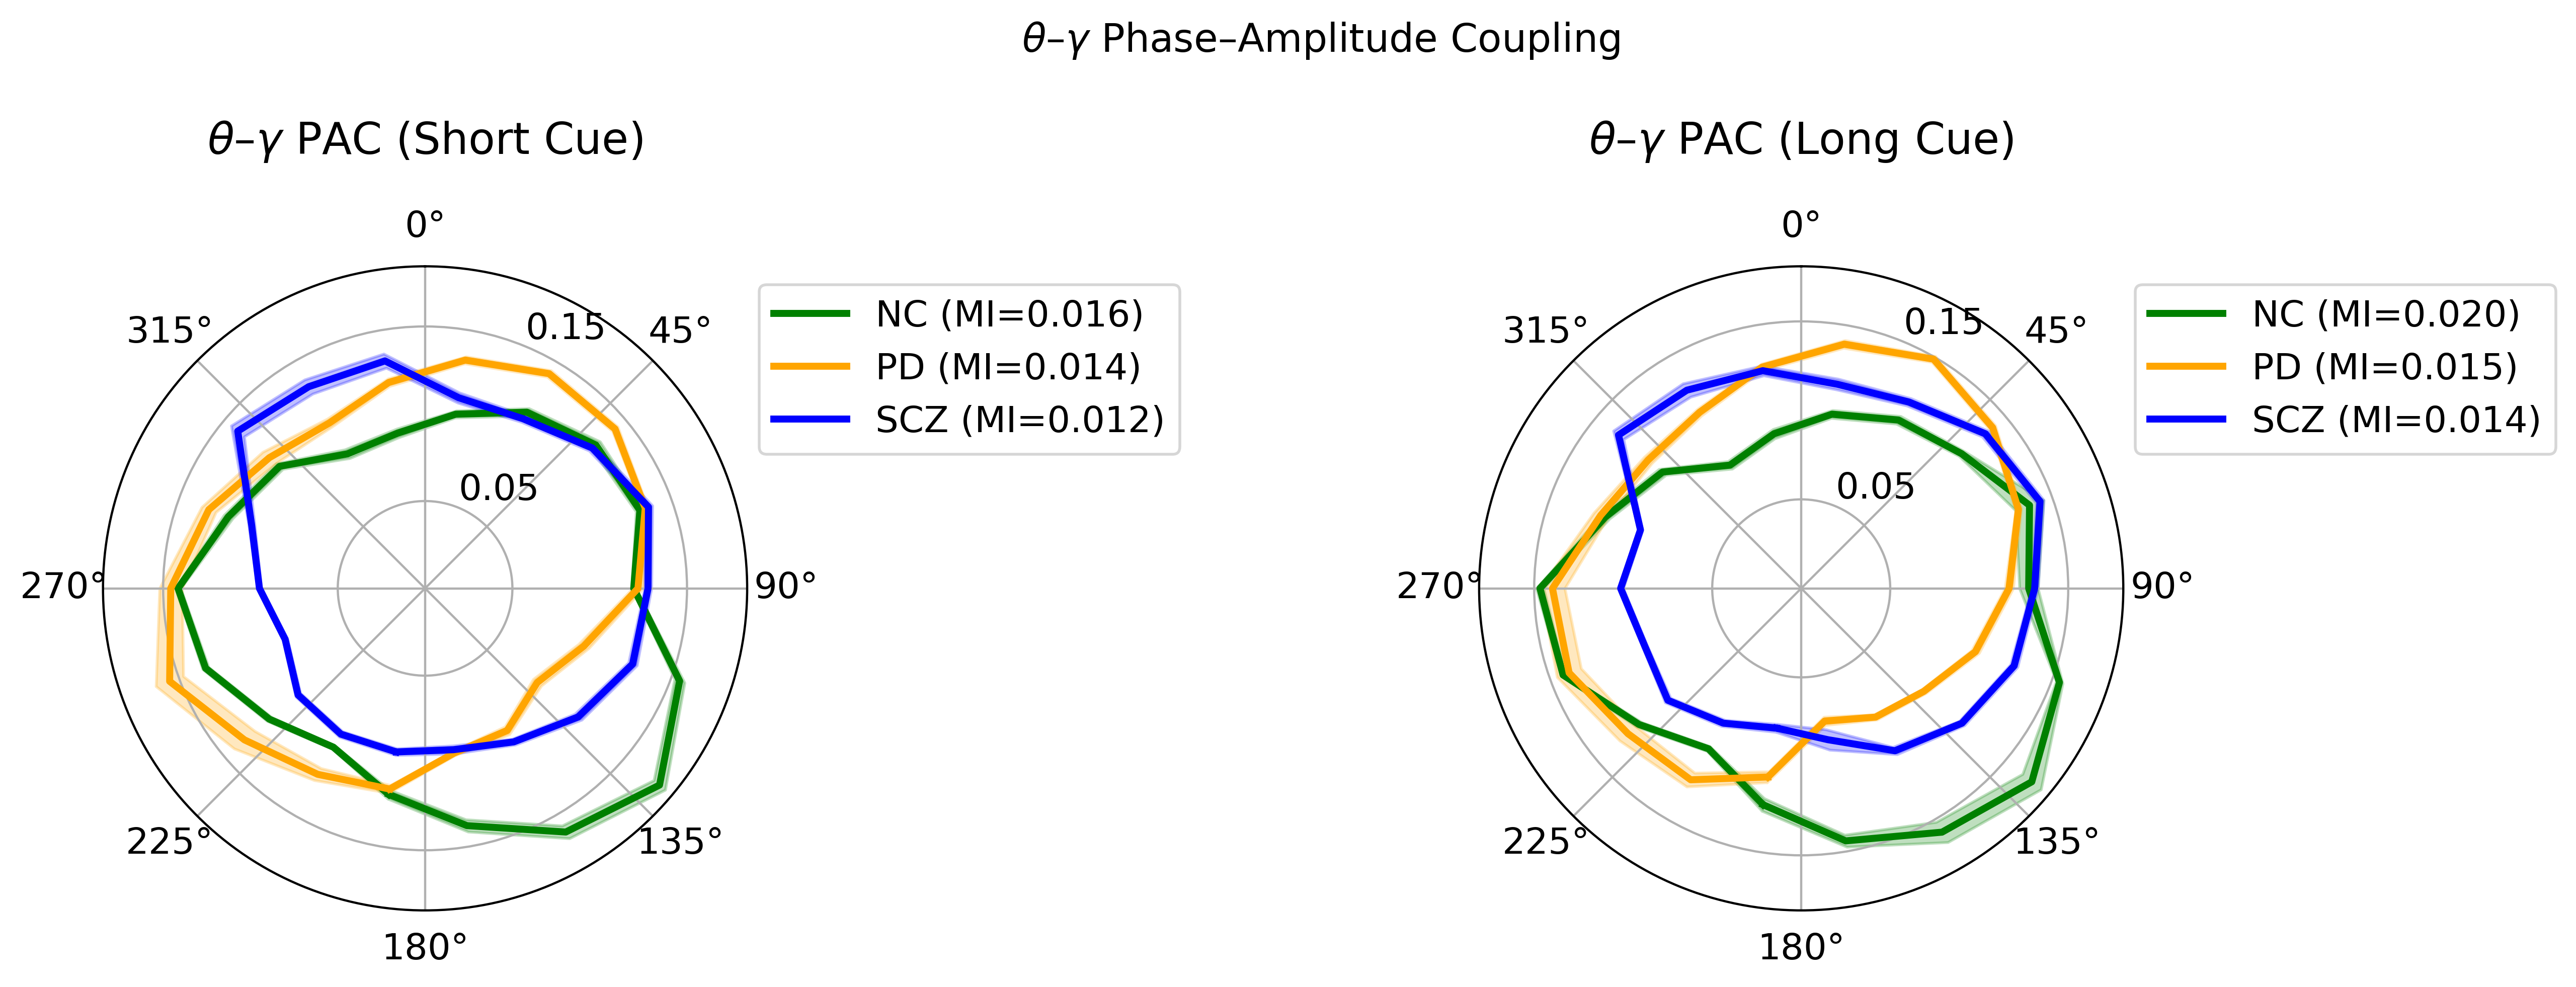

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert

# ===================== Parameters =====================
dt = 0.002
fs = 1 / dt

theta_band = (4, 8)
gamma_band = (30, 80)
n_bins = 18

plt.rcParams.update({'font.size': 13, 'figure.dpi': 400})

colors = {'NC':'green','PD':'orange','SCZ':'blue'}

# ===================== Helpers =====================
def ensure_array(x):
    if isinstance(x, list):
        return np.stack(x)
    return np.asarray(x)

def bandpass_filter(signal, fs, low, high, order=4):
    nyq = fs/2
    b,a = butter(order,[low/nyq,high/nyq],btype='band')
    return filtfilt(b,a,signal)

def compute_pac(value_signal,gamma_signal,fs,theta_band,gamma_band,n_bins):

    value_signal=value_signal-np.mean(value_signal)
    theta_filt=bandpass_filter(value_signal,fs,*theta_band)
    theta_phase=np.angle(hilbert(theta_filt))

    gamma_signal=gamma_signal-np.mean(gamma_signal)
    gamma_filt=bandpass_filter(gamma_signal,fs,*gamma_band)
    gamma_amp=np.abs(hilbert(gamma_filt))

    bins=np.linspace(-np.pi,np.pi,n_bins+1)
    bin_centers=(bins[:-1]+bins[1:])/2

    amp_means=np.zeros(n_bins)

    for i in range(n_bins):
        idx=(theta_phase>=bins[i])&(theta_phase<bins[i+1])
        if np.any(idx):
            amp_means[i]=np.mean(gamma_amp[idx])

    amp_dist=amp_means/np.sum(amp_means)
    uniform=np.ones(n_bins)/n_bins
    mi=np.sum(amp_dist*np.log((amp_dist+1e-12)/uniform))

    return bin_centers,amp_means,mi

def compute_pac_trials(value_trials,d1_trials,fs,theta_band,gamma_band,n_bins):

    value_trials=ensure_array(value_trials)
    d1_trials=ensure_array(d1_trials)

    amp_all=[]
    mi_all=[]

    for v,d1 in zip(value_trials,d1_trials):

        gamma_signal=d1.mean(axis=0)

        phases,amps,mi=compute_pac(v,gamma_signal,fs,theta_band,gamma_band,n_bins)

        amp_all.append(amps)
        mi_all.append(mi)

    amp_all=np.asarray(amp_all)

    return phases,amp_all.mean(0),amp_all.std(0),np.mean(mi_all),np.std(mi_all)

# ===================== Compute PAC =====================
pac={'short':{},'long':{}}

pac['short']['NC']=compute_pac_trials(nc_value_short,nc_d1_short,fs,theta_band,gamma_band,n_bins)
pac['short']['PD']=compute_pac_trials(pd_value_short,pd_d1_short,fs,theta_band,gamma_band,n_bins)
pac['short']['SCZ']=compute_pac_trials(sh_value_short,sh_d1_short,fs,theta_band,gamma_band,n_bins)

pac['long']['NC']=compute_pac_trials(nc_value_long,nc_d1_long,fs,theta_band,gamma_band,n_bins)
pac['long']['PD']=compute_pac_trials(pd_value_long,pd_d1_long,fs,theta_band,gamma_band,n_bins)
pac['long']['SCZ']=compute_pac_trials(sh_value_long,sh_d1_long,fs,theta_band,gamma_band,n_bins)

# ===================== Plotting =====================
def plot_pac_polar(ax,pac_dict,title):

    for label,(phases,mean_amp,std_amp,mi_mean,mi_std) in pac_dict.items():

        phases_ext=np.append(phases,phases[0])
        mean_ext=np.append(mean_amp,mean_amp[0])
        std_ext=np.append(std_amp,std_amp[0])

        ax.plot(phases_ext,mean_ext,
                color=colors[label],
                lw=2.5,
                label=f'{label} (MI={mi_mean:.3f})')

        ax.fill_between(phases_ext,
                        mean_ext-std_ext,
                        mean_ext+std_ext,
                        color=colors[label],
                        alpha=0.25)

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    # --- radial ticks (only two) ---
    rmax = ax.get_rmax()
    ax.set_rticks([0.05, 0.15])
    ax.set_rlabel_position(22.5)

    ax.set_title(title, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.7,1.0))

# ---- Figure ----
fig=plt.figure(figsize=(14,5))

ax1=fig.add_subplot(121,projection='polar')
ax2=fig.add_subplot(122,projection='polar')

plot_pac_polar(ax1,pac['short'],r'$\theta$–$\gamma$ PAC (Short Cue)')
plot_pac_polar(ax2,pac['long'], r'$\theta$–$\gamma$ PAC (Long Cue)')

plt.suptitle(r'$\theta$–$\gamma$ Phase–Amplitude Coupling',fontsize=14)
plt.tight_layout()
plt.savefig('pac_theta_gamma_stats.png',dpi=400)
plt.show()

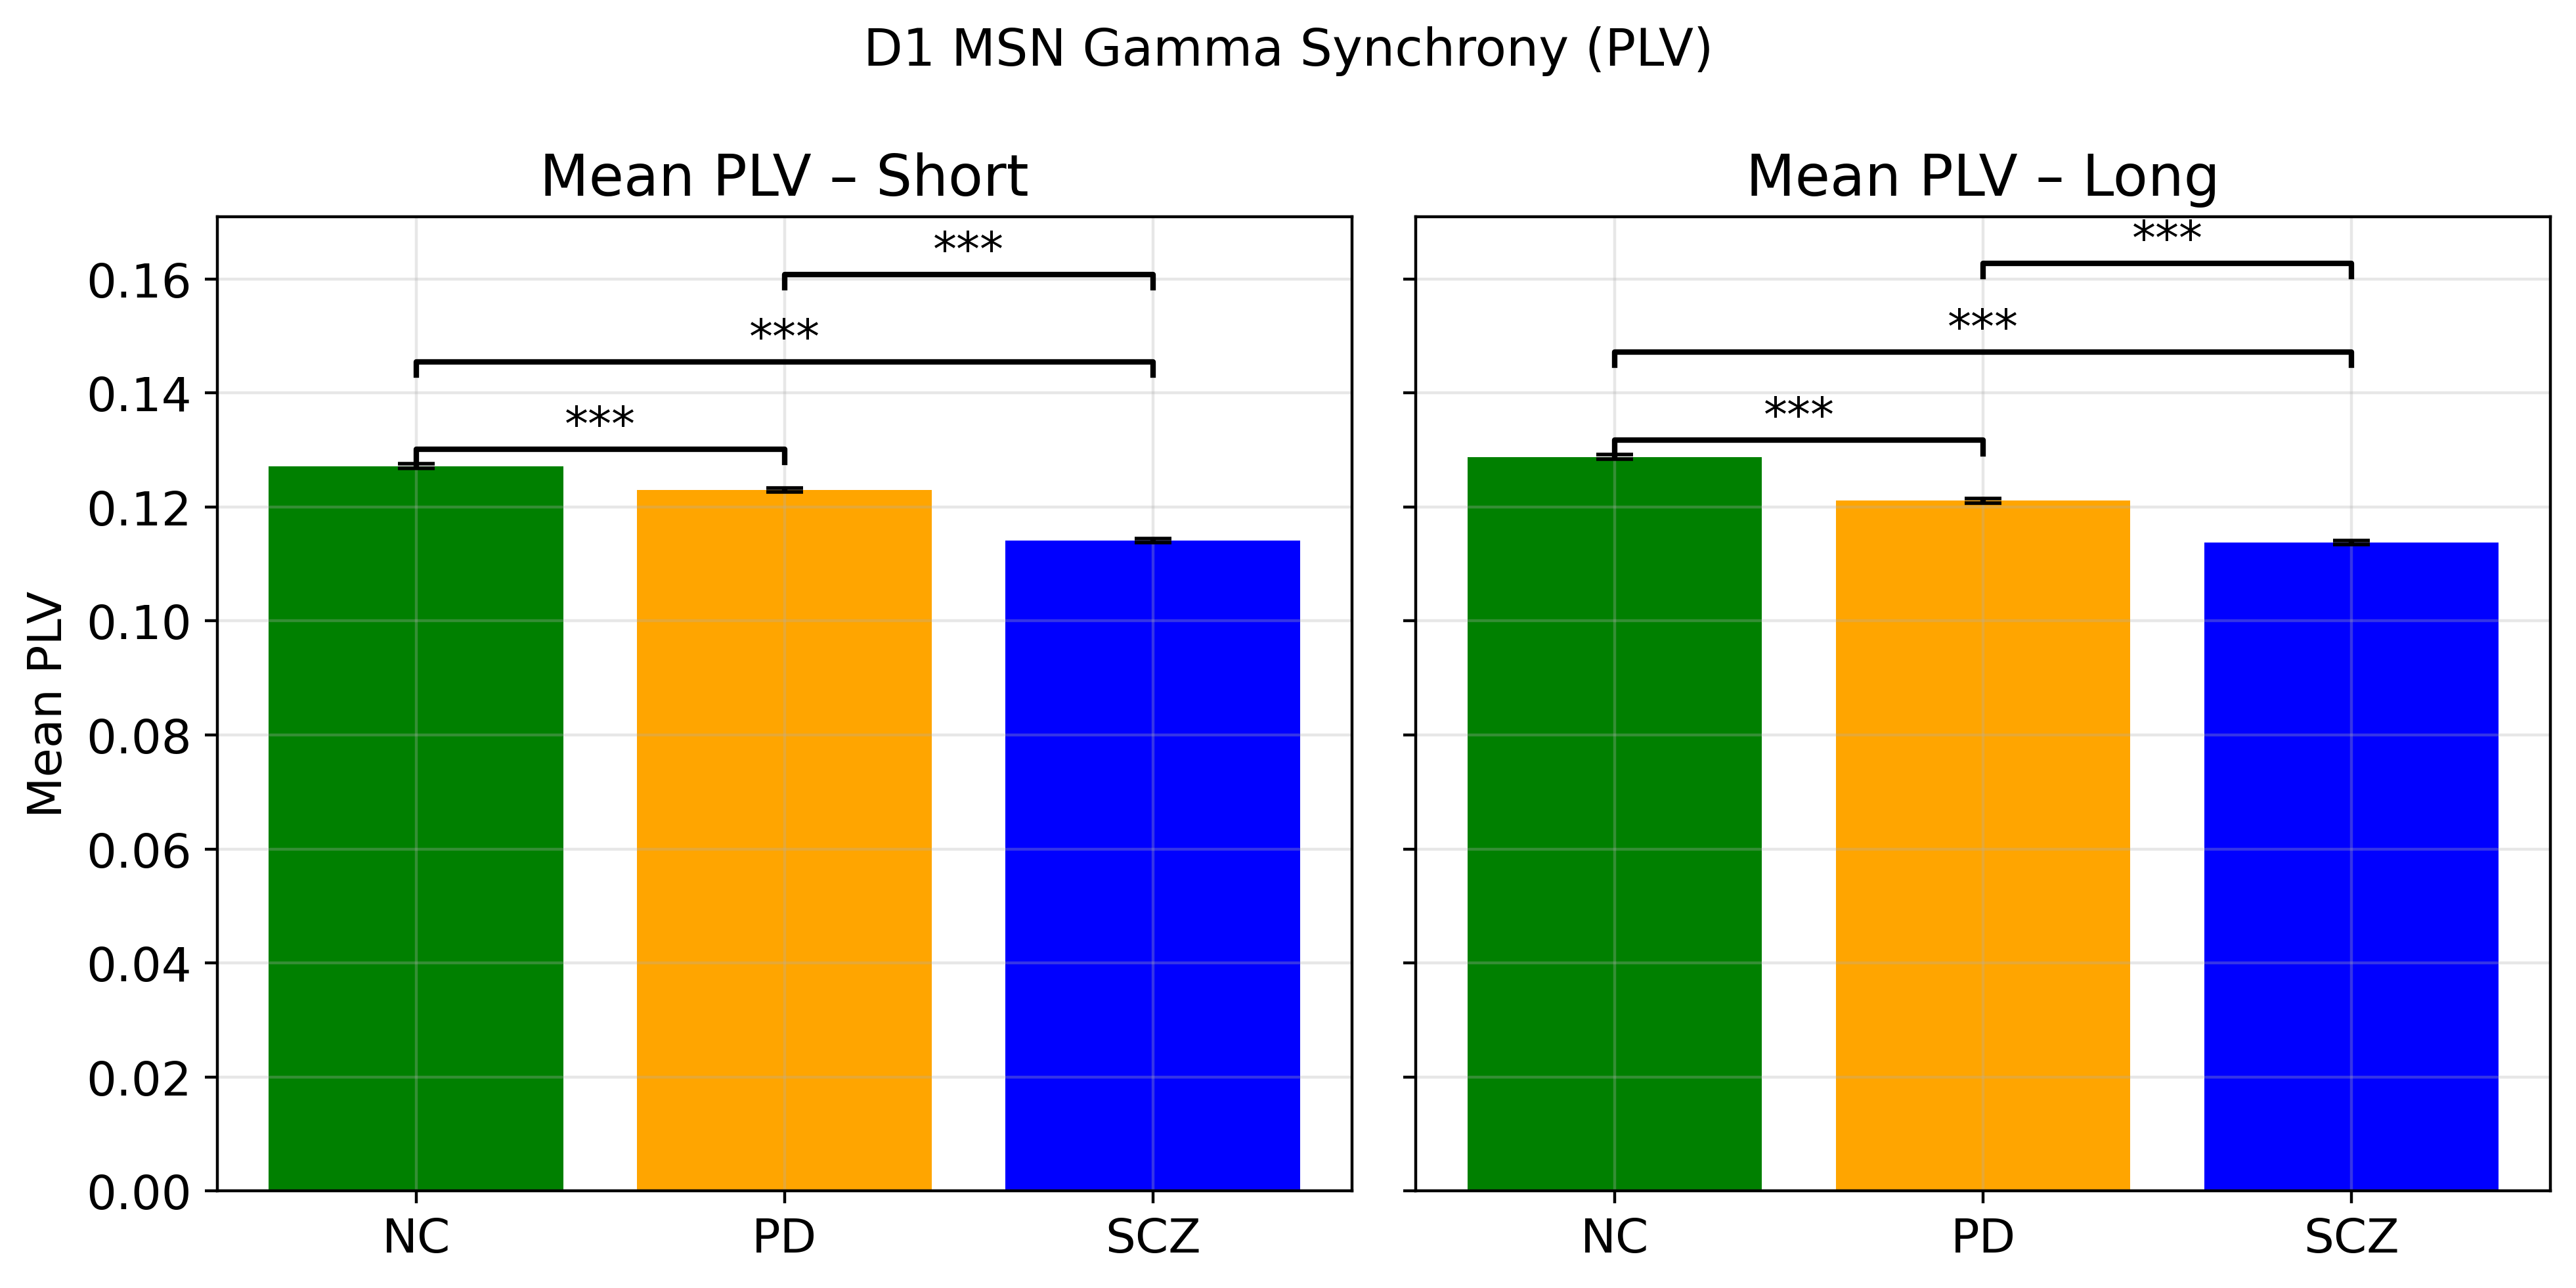

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert
from scipy.stats import ttest_ind

# ===================== Parameters =====================
dt = 0.002
fs = 1/dt
gamma_band=(30,80)

groups=['NC','PD','SCZ']
colors={'NC':'green','PD':'orange','SCZ':'blue'}

# ===================== Helpers =====================
def ensure_array(x):
    if isinstance(x,list):
        return np.stack(x)
    return np.asarray(x)

def bandpass_filter(signal,fs,low,high,order=4):
    nyq=fs/2
    b,a=butter(order,[low/nyq,high/nyq],btype='band')
    return filtfilt(b,a,signal)

def compute_plv_timecourse(d1_osc,fs,gamma_band):

    phases=[]
    for osc in d1_osc:
        osc=osc-np.mean(osc)
        filt=bandpass_filter(osc,fs,*gamma_band)
        phases.append(np.angle(hilbert(filt)))

    phases=np.asarray(phases)
    return np.abs(np.mean(np.exp(1j*phases),axis=0))

def compute_plv_trials(d1_trials,fs,gamma_band):

    d1_trials=ensure_array(d1_trials)

    plv_mean=[]

    for trial in d1_trials:
        t=compute_plv_timecourse(trial,fs,gamma_band)
        # t_trim=t[100:]   # ignore transient
        plv_mean.append(t.mean())

    return np.asarray(plv_mean)

def p_to_star(p):
    if p<1e-3:return'***'
    if p<1e-2:return'**'
    if p<0.05:return'*'
    return None

def add_sig(ax,x1,x2,y,h,text):
    ax.plot([x1,x1,x2,x2],[y,y+h,y+h,y],lw=1.5,c='k')
    ax.text((x1+x2)/2,y+h,text,ha='center',va='bottom')

# ===================== Compute =====================
stats={'short':{},'long':{}}

stats['short']['NC']=compute_plv_trials(nc_d1_short,fs,gamma_band)
stats['short']['PD']=compute_plv_trials(pd_d1_short,fs,gamma_band)
stats['short']['SCZ']=compute_plv_trials(sh_d1_short,fs,gamma_band)

stats['long']['NC']=compute_plv_trials(nc_d1_long,fs,gamma_band)
stats['long']['PD']=compute_plv_trials(pd_d1_long,fs,gamma_band)
stats['long']['SCZ']=compute_plv_trials(sh_d1_long,fs,gamma_band)

# ===================== Plot =====================
fig,axes=plt.subplots(1,2,figsize=(10,5),sharey=True)

x=np.arange(len(groups))
pairs=[(0,1),(0,2),(1,2)]

for ax,cond,title in zip(
        axes,
        ['short','long'],
        ['Mean PLV – Short','Mean PLV – Long']):

    means=[stats[cond][g].mean() for g in groups]
    stds =[stats[cond][g].std() for g in groups]

    ax.bar(x,means,yerr=stds,capsize=5,
           color=[colors[g] for g in groups])

    y_base=max(means)+max(stds)*1.5
    step=y_base*0.12
    h=step*0.15

    for i,(a,b) in enumerate(pairs):
        d1=stats[cond][groups[a]]
        d2=stats[cond][groups[b]]
        _,p=ttest_ind(d1,d2,equal_var=False)
        star=p_to_star(p)
        if star:
            add_sig(ax,a,b,y_base+i*step,h,star)

    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_title(title)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Mean PLV')

plt.suptitle('D1 MSN Gamma Synchrony (PLV)',fontsize=14)
plt.tight_layout()
plt.savefig('plv_stats.png',dpi=400)
plt.show()

In [50]:
np.save('plv_data.npy', stats, allow_pickle=True)

In [52]:
np.save('pac_data.npy', pac, allow_pickle=True)